<a href="https://colab.research.google.com/github/hiralgundecha/machinelearning/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install scikit-learn


In [24]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
df = pd.read_csv("/content/pizza_v1.csv")
# Display the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
# Display the column names
print("Column names:")
for col in df.columns:
    print(col)
# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())
df=df.drop('extra_cheese',axis=1)
df.head()


Number of rows: 129
Number of columns: 8
Column names:
company
price_rupiah
diameter
topping
variant
size
extra_sauce
extra_cheese
First 5 rows of the DataFrame:


,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese
0,A,"Rp235,000",22.0,chicken,double_signature,jumbo,yes,yes
1,A,"Rp198,000",20.0,papperoni,double_signature,jumbo,yes,yes
2,A,"Rp120,000",16.0,mushrooms,double_signature,reguler,yes,yes
3,A,"Rp155,000",14.0,smoked beef,double_signature,reguler,yes,no
4,A,"Rp248,000",18.0,mozzarella,double_signature,jumbo,yes,no


,company,price_rupiah,diameter,topping,variant,size,extra_sauce
0,A,"Rp235,000",22.0,chicken,double_signature,jumbo,yes
1,A,"Rp198,000",20.0,papperoni,double_signature,jumbo,yes
2,A,"Rp120,000",16.0,mushrooms,double_signature,reguler,yes
3,A,"Rp155,000",14.0,smoked beef,double_signature,reguler,yes
4,A,"Rp248,000",18.0,mozzarella,double_signature,jumbo,yes


In [32]:
df = df.drop(columns=['extra_sauce'])
print(df)

    company price_rupiah  diameter      topping           variant     size
0         A    Rp235,000      22.0      chicken  double_signature    jumbo
1         A    Rp198,000      20.0    papperoni  double_signature    jumbo
2         A    Rp120,000      16.0    mushrooms  double_signature  reguler
3         A    Rp155,000      14.0  smoked beef  double_signature  reguler
4         A    Rp248,000      18.0   mozzarella  double_signature    jumbo
..      ...          ...       ...          ...               ...      ...
124       E     Rp39,000       8.5         tuna        spicy tuna    small
125       E     Rp72,000      12.0         tuna        spicy tuna   medium
126       E     Rp99,000      14.0         tuna        spicy tuna    large
127       E     Rp44,000       8.5         meat   BBQ_meat_fiesta    small
128       E     Rp78,000      12.0         meat   BBQ_meat_fiesta   medium

[129 rows x 6 columns]


In [33]:
# Clean 'price_rupiah' column
df['price_rupiah'] = df['price_rupiah'].str.replace('Rp', '').str.replace(',', '').astype(float)

# Display the cleaned column and its data type
print("Price_rupiah after cleaning:")
display(df[['price_rupiah']].head())
print(f"Data type of price_rupiah: {df['price_rupiah'].dtype}")

Price_rupiah after cleaning:


,price_rupiah
0,235000.0
1,198000.0
2,120000.0
3,155000.0
4,248000.0


Data type of price_rupiah: float64


Now that `price_rupiah` is clean and numerical, let's visualize the distribution of `price_rupiah` and `diameter` using histograms, and then examine the counts of categorical features.

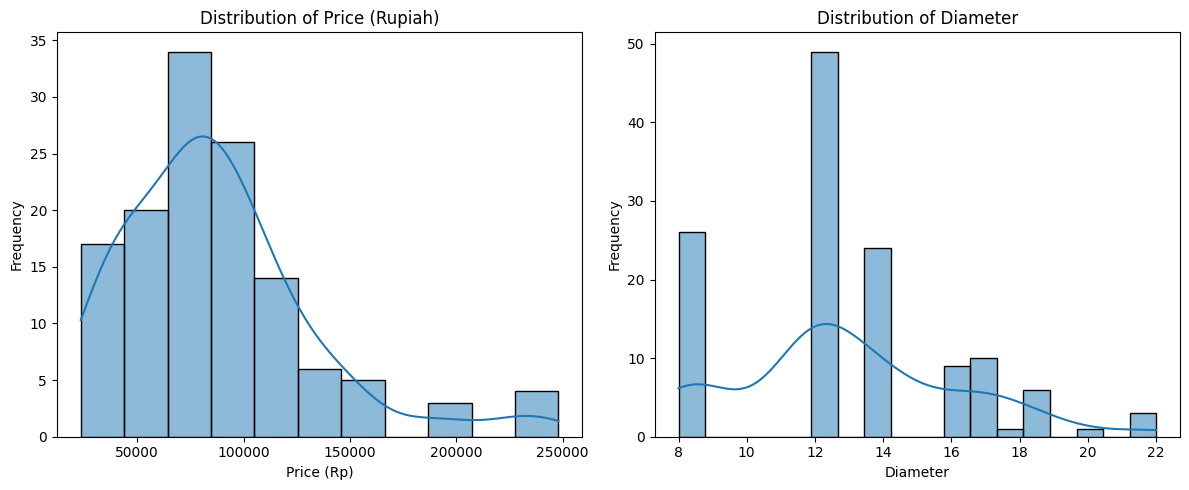

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price_rupiah'], kde=True)
plt.title('Distribution of Price (Rupiah)')
plt.xlabel('Price (Rp)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['diameter'], kde=True)
plt.title('Distribution of Diameter')
plt.xlabel('Diameter')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Next, let's visualize the counts of the categorical features: `company`, `topping`, `variant`, and `size`.

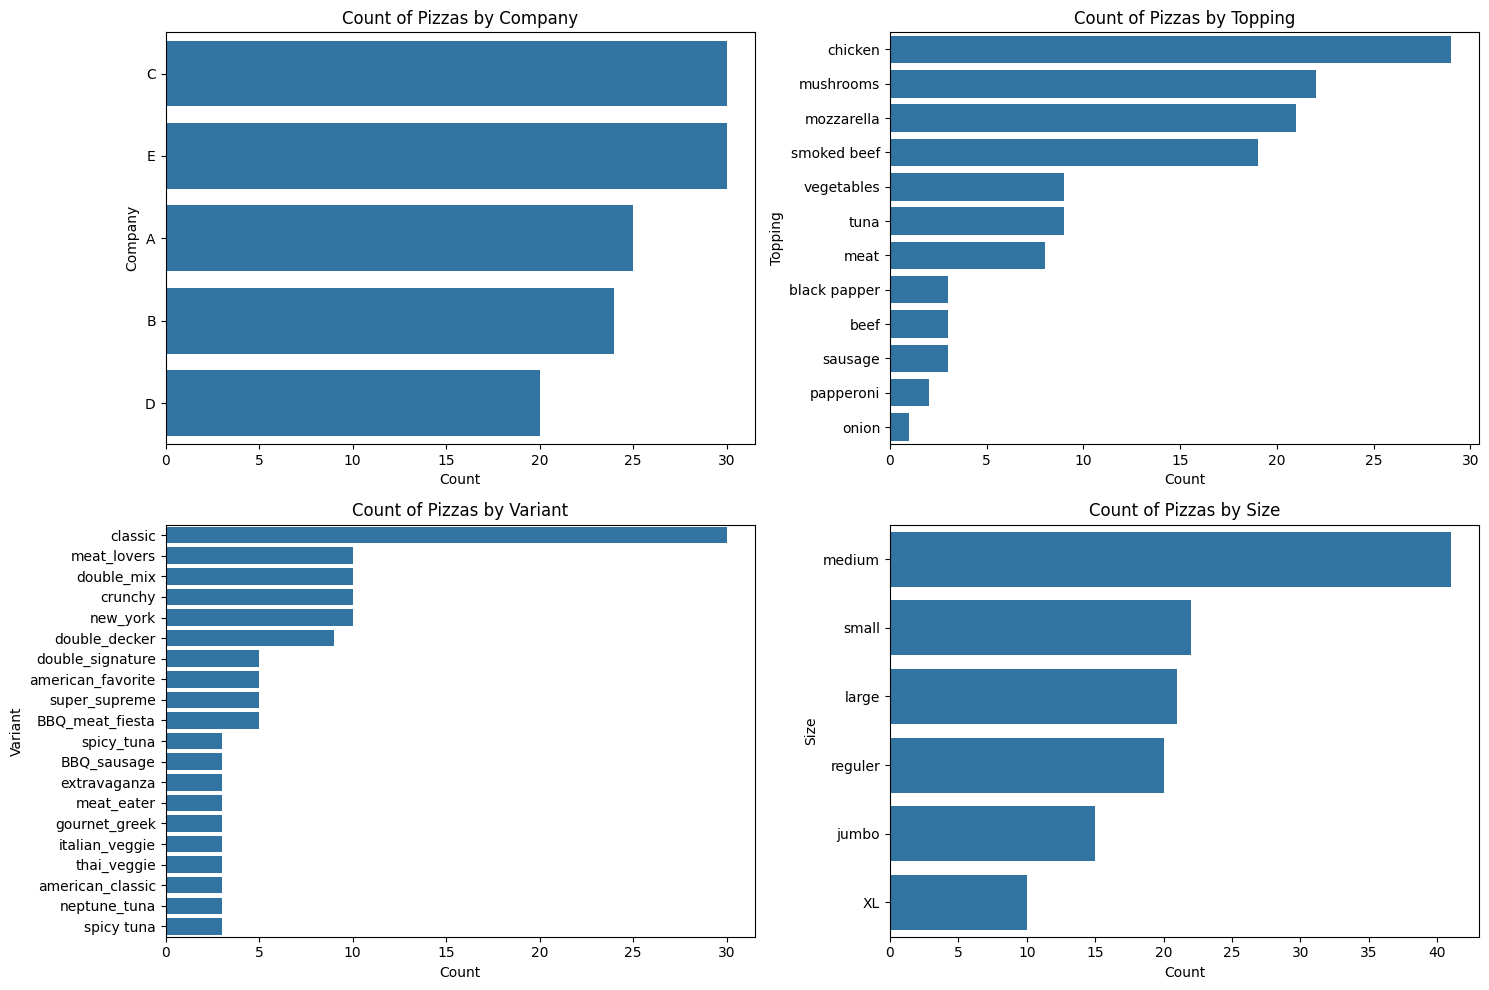

In [35]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(y=df['company'], order=df['company'].value_counts().index)
plt.title('Count of Pizzas by Company')
plt.xlabel('Count')
plt.ylabel('Company')

plt.subplot(2, 2, 2)
sns.countplot(y=df['topping'], order=df['topping'].value_counts().index)
plt.title('Count of Pizzas by Topping')
plt.xlabel('Count')
plt.ylabel('Topping')

plt.subplot(2, 2, 3)
sns.countplot(y=df['variant'], order=df['variant'].value_counts().index)
plt.title('Count of Pizzas by Variant')
plt.xlabel('Count')
plt.ylabel('Variant')

plt.subplot(2, 2, 4)
sns.countplot(y=df['size'], order=df['size'].value_counts().index)
plt.title('Count of Pizzas by Size')
plt.xlabel('Count')
plt.ylabel('Size')

plt.tight_layout()
plt.show()

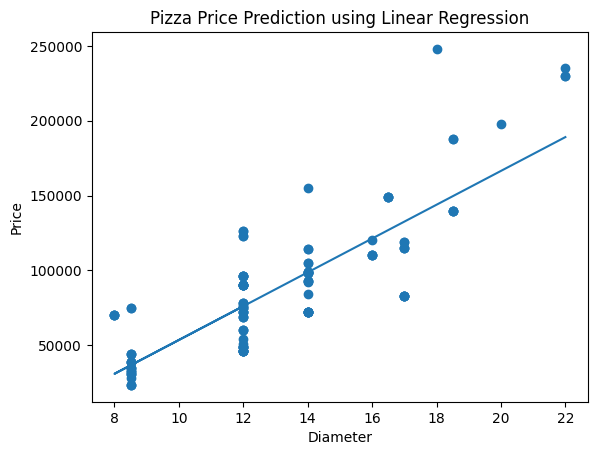

In [37]:
X = df[['diameter']]
y = df['price_rupiah']

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict prices
df['predicted_price'] = model.predict(X)

# Plot Actual vs Predicted
plt.figure()
plt.scatter(df['diameter'], y)
plt.plot(df['diameter'], df['predicted_price'])
plt.xlabel("Diameter")
plt.ylabel("Price")
plt.title("Pizza Price Prediction using Linear Regression")
plt.show()

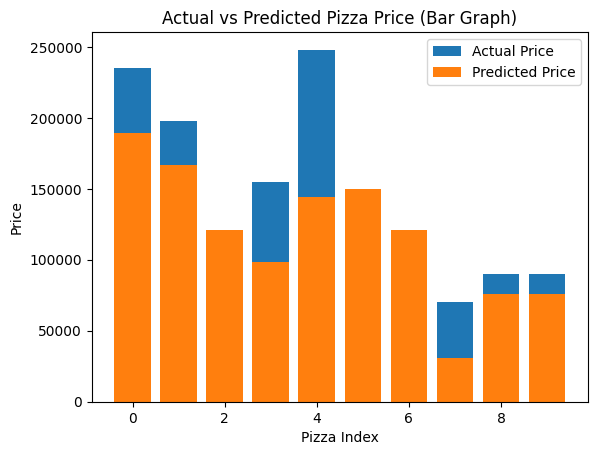

In [40]:
X = df[['diameter']]
y = df['price_rupiah']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
df['predicted_price'] = model.predict(X)

# Take first 10 records for bar graph
df_small = df.head(10)

# Bar chart
plt.figure()
x = range(len(df_small))

plt.bar(x, df_small['price_rupiah'], label='Actual Price')
plt.bar(x, df_small['predicted_price'], label='Predicted Price')

plt.xlabel("Pizza Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Pizza Price (Bar Graph)")
plt.legend()
plt.show()

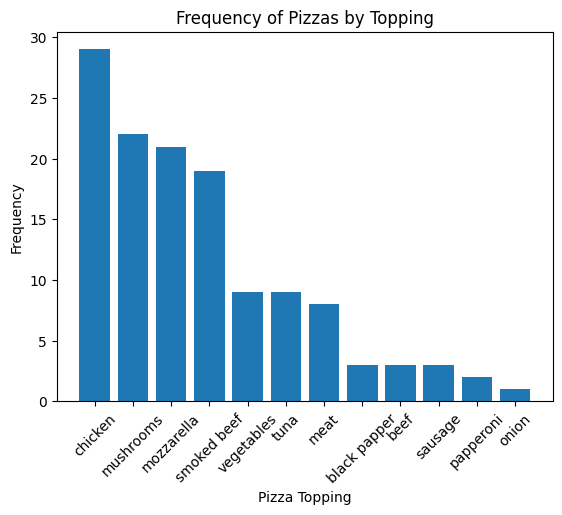

In [41]:
topping_freq = df['topping'].value_counts()

# Bar chart
plt.figure()
plt.bar(topping_freq.index, topping_freq.values)
plt.xlabel("Pizza Topping")
plt.ylabel("Frequency")
plt.title("Frequency of Pizzas by Topping")
plt.xticks(rotation=45)
plt.show()

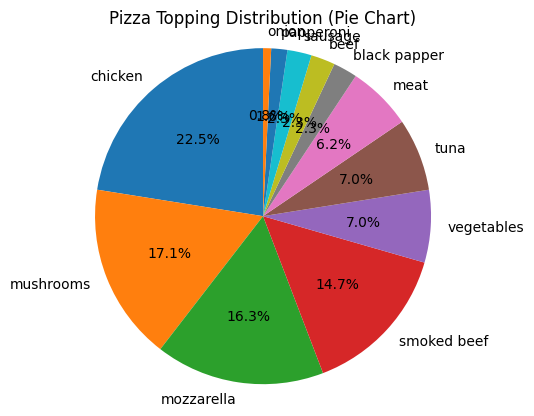

In [42]:
topping_freq = df['topping'].value_counts()

# Pie chart
plt.figure()
plt.pie(
    topping_freq.values,
    labels=topping_freq.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Pizza Topping Distribution (Pie Chart)")
plt.axis('equal')
plt.show()

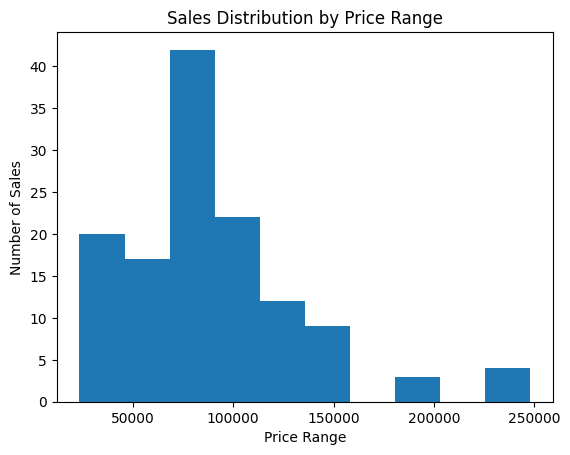

In [46]:
plt.figure()
plt.hist(df['price_rupiah'])
plt.xlabel("Price Range")
plt.ylabel("Number of Sales")
plt.title("Sales Distribution by Price Range")
plt.show()

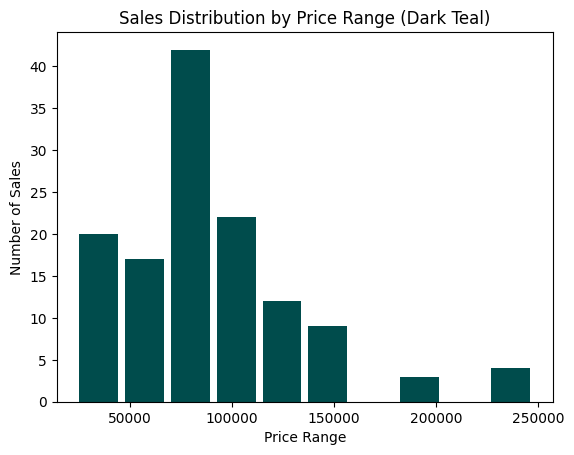

In [47]:
plt.figure()
plt.hist(
    df['price_rupiah'],
    bins=10,
    rwidth=0.85,        # space between bars
    color='#004C4C'     # dark teal
)

plt.xlabel("Price Range")
plt.ylabel("Number of Sales")
plt.title("Sales Distribution by Price Range (Dark Teal)")
plt.show()